# Define analysis goals or questions

- What is the top products by revenue?
- Country level revenue analysis.
- What is the most category are ordered?
- Monthly trend analysis.
- Is there a relationship between the quantitiy and revenue?

# Load cleaned dataset

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("data/electronics_store_cleaned.csv")
data.head()

,TransactionID,Product,Category,Quantity,UnitPrice,CustomerID,Country,OrderDate,Revenue,Month,Year
0,T1,Phone,Mobile,3,500.0,119.0,UK,2025-02-14,1500.0,2,2025
1,T2,Mouse,Accessories,4,15.0,136.0,Italy,2025-01-04,60.0,1,2025
2,T3,Laptop,Computers,1,900.0,147.0,Italy,2025-03-10,900.0,3,2025
3,T4,Tablet,Mobile,3,300.0,145.0,France,2025-01-12,900.0,1,2025
4,T5,Laptop,Computers,3,900.0,136.0,France,2025-01-01,2700.0,1,2025


# Verify data types and Revenue column

In [59]:
data.dtypes

TransactionID        str
Product              str
Category             str
Quantity           int64
UnitPrice        float64
CustomerID           str
Country              str
OrderDate            str
Revenue          float64
Month              int64
Year               int64
dtype: object

In [60]:
data["OrderDate"] = pd.to_datetime(data["OrderDate"])
data.dtypes

TransactionID               str
Product                     str
Category                    str
Quantity                  int64
UnitPrice               float64
CustomerID                  str
Country                     str
OrderDate        datetime64[us]
Revenue                 float64
Month                     int64
Year                      int64
dtype: object

In [61]:
data[data["Revenue"] <= 0]

,TransactionID,Product,Category,Quantity,UnitPrice,CustomerID,Country,OrderDate,Revenue,Month,Year


# Descriptive statistics for Quantity, UnitPrice, Revenue

In [62]:
data[["Quantity", "UnitPrice", "Revenue"]].describe()

,Quantity,UnitPrice,Revenue
count,300.000000,300.000000,300.000000
mean,2.563333,323.166667,883.216667
std,1.127042,315.806774,1042.544596
min,1.000000,15.000000,15.000000
25%,2.000000,30.000000,75.000000
50%,3.000000,200.000000,500.000000
75%,4.000000,500.000000,1200.000000
max,4.000000,900.000000,3600.000000


# Top products by revenue

In [63]:
products = data.groupby("Product")["Revenue"].sum().sort_values(ascending = False).reset_index()
products.index += 1
products

,Product,Revenue
1,Laptop,145800.0
2,Phone,53000.0
3,Tablet,32400.0
4,Monitor,25200.0
5,Headphones,4560.0
6,Keyboard,2400.0
7,Mouse,1605.0


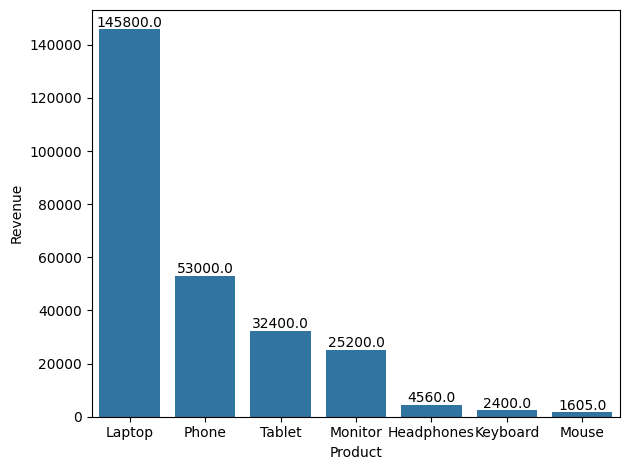

In [64]:
bars = sns.barplot(data = products, x = "Product", y = "Revenue")
for bar in bars.patches:
    height = bar.get_height()
    plt.annotate(f"{height}", xy = (bar.get_x() + bar.get_width() / 2, height + 1000), ha = "center")
plt.tight_layout();

# Country-level revenue analysis

In [65]:
countries = data.groupby("Country")["Revenue"].sum().sort_values(ascending = False).reset_index()
countries.index += 1
countries

,Country,Revenue
1,France,67765.0
2,UK,59745.0
3,Italy,49465.0
4,Germany,44000.0
5,Spain,43990.0


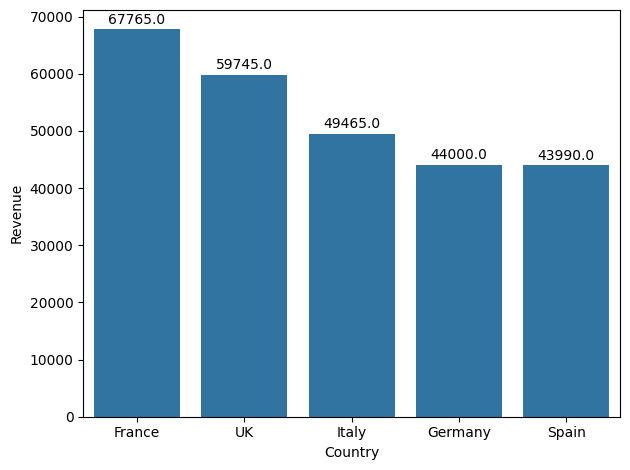

In [66]:
bars = sns.barplot(data = countries, x = "Country", y = "Revenue")
for bar in bars.patches:
    height = bar.get_height()
    plt.annotate(f"{height}", xy = (bar.get_x() + bar.get_width() / 2, height + 1000), ha = "center")
plt.tight_layout();

# Category analysis

In [67]:
data["Category"].value_counts()

Category
Mobile         82
Accessories    77
Computers      55
Display        52
Audio          34
Name: count, dtype: int64

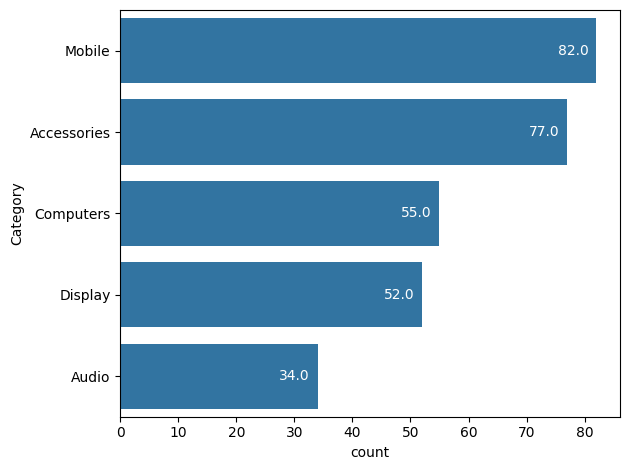

In [68]:
bars = sns.countplot(data["Category"])
for bar in bars.patches:
    width = bar.get_width()
    plt.annotate(f"{width}", xy = (width - 4, bar.get_y() + bar.get_height() / 2), ha = "center", va = "center", color = "white")
plt.tight_layout();

# Monthly trend analysis

In [79]:
months = data.groupby("Month")[["Revenue", "Quantity"]].sum().reset_index()
months

,Month,Revenue,Quantity
0,1,59835.0,181
1,2,68350.0,195
2,3,66615.0,183
3,4,70165.0,210


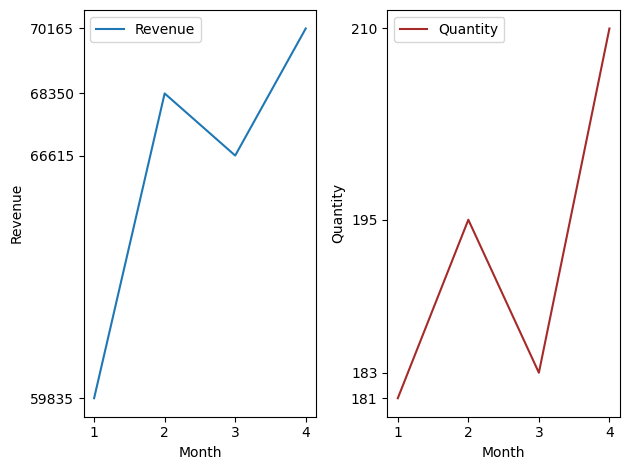

In [119]:
fig, ax = plt.subplots(1, 2)
sns.lineplot(data = months, x = "Month", y = "Revenue", errorbar = None, label = "Revenue", ax = ax[0])
sns.lineplot(data = months, x = "Month", y = "Quantity", errorbar = None, label = "Quantity", ax = ax[1], color = "brown")
ax[0].set_yticks(months["Revenue"])
ax[1].set_yticks(months["Quantity"])
plt.tight_layout()
plt.legend();

# Relationship analysis

In [134]:
corr = data[["Quantity", "Revenue"]].corr()
corr

,Quantity,Revenue
Quantity,1.000000,0.456138
Revenue,0.456138,1.000000


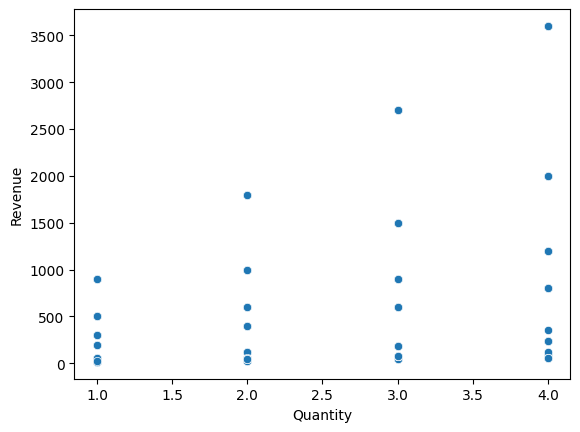

In [127]:
sns.scatterplot(data = data, x = "Quantity", y = "Revenue");

<Axes: >

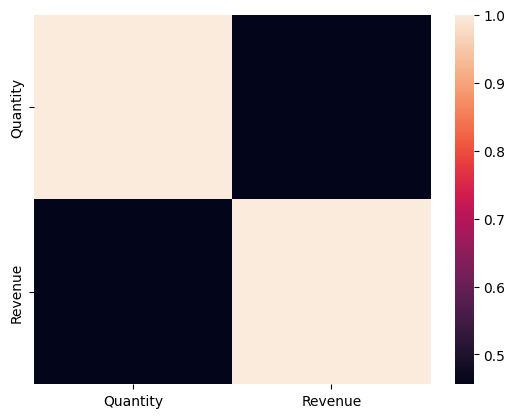

In [135]:
sns.heatmap(corr)

# Insight generation

- Heighst product by revenue => Laptop
- Least products by revenue => Headphones - Keyboard - Mouse
#
- Heighst country-level revenue => France - UK
- Least country-level revenue => Germany - Spain
#
- Heighst catogries by orders => Mobile - Accessories
- Least categories by orders => Headphones - Keyboard - Mouse
#
- There isn't a relationship between quantity and revenue

# Final business report

- Audio category has the least number of orders and headphones have the least revenue, so we must work hardly to improve this category exactly and make a deep study to find the reason of this problem.
- Germany and Spain have the least revenue, so we must increase the study on thier market and the most ordered products there, and We must sure that the prices is suitable to these countries.
- Although accessories category has the heighst number of orders, keyboard and mouse have the least revenue, that will be caused by the wrong pricing.
- There isn't any relationship between quantity and revenue, so we musn't increase the production of any product without a deep study